# DPO FINE-TUNING: B2_SFT → B2_DPO

In [1]:
!pip install -q transformers peft bitsandbytes accelerate trl  evaluate bert_score rouge-score nltk openai huggingface_hub

In [2]:
import os, json, random, re, warnings, gc, torch, numpy as np
from PIL import Image
from transformers import AutoProcessor, Qwen2VLForConditionalGeneration, BitsAndBytesConfig
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import DPOTrainer, DPOConfig
from datasets import Dataset
import evaluate
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer as rs
import nltk, warnings
warnings.filterwarnings("ignore")
for p in ["wordnet","omw-1.4"]:
    try: nltk.data.find(f"corpora/{p}")
    except: nltk.download(p, quiet=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


In [ ]:
# import zipfile
# from huggingface_hub import hf_hub_download
# import shutil

# os.makedirs("data/openvivqa/dev", exist_ok=True)

# def maybe_dl(filename, dest):
#     p = hf_hub_download("uitnlp/OpenViVQA-dataset", filename, repo_type="dataset")
#     if filename.endswith(".zip"):
#         out = os.path.join(dest, filename.replace(".zip",""))
#         if not os.path.exists(out):
#             with zipfile.ZipFile(p) as z: z.extractall(dest)
#     else:
#         dst = os.path.join(dest, filename)
#         if not os.path.exists(dst): shutil.copy(p, dst)

# maybe_dl("dev-images.zip", "data/openvivqa/dev")
# maybe_dl("vlsp2023_dev_data.json", "data/openvivqa")

# with open("data/openvivqa/vlsp2023_dev_data.json", encoding="utf-8") as f:
#     raw = json.load(f)

# all_samples = []
# for ann in raw["annotations"].values():
#     fname = raw["images"].get(str(ann["image_id"]))
#     if fname:
#         p = f"data/openvivqa/dev/dev-images/{fname}"
#         if os.path.exists(p):
#             all_samples.append({"image": p, "question": ann["question"], "answer": ann["answer"]})

# random.seed(42)
# pool = random.sample(all_samples, min(150, len(all_samples)))
# print(f"Pool: {len(pool)} mẫu — sẽ dùng 100 cặp đầu tiên để tạo preference data")

In [3]:
import zipfile
from huggingface_hub import hf_hub_download
import shutil

with open("/kaggle/input/datasets/windyy261203/openvivqa/dev-annotations.json", encoding="utf-8") as f:
    raw = json.load(f)

all_samples = []
for ann in raw["annotations"].values():
    fname = raw["images"].get(str(ann["image_id"]))
    if fname:
        p = f"/kaggle/input/datasets/windyy261203/openvivqa/dev-images/{fname}"
        if os.path.exists(p):
            all_samples.append({"image": p, "question": ann["question"], "answer": ann["answer"]})

random.seed(42)
pool = random.sample(all_samples, min(200, len(all_samples)))
print(f"Pool: {len(pool)} mẫu — sẽ dùng 200 cặp đầu tiên để tạo preference data")

Pool: 200 mẫu — sẽ dùng 200 cặp đầu tiên để tạo preference data


In [4]:
BASE_ID     = "Qwen/Qwen2-VL-2B-Instruct"
SFT_ADAPTER = "/kaggle/input/models/nguynngqun/qwen2vl-finetuned/pytorch/default/1/qwen2vl_b2_final"   # checkpoint B2

processor = AutoProcessor.from_pretrained(BASE_ID, max_pixels=313600)

print("Đang tải base model...")
base_model = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_ID,
    device_map={"": device},
    torch_dtype=torch.float16 if device=="cuda" else torch.float32
)

print("Đang gắn SFT adapter (B2)...")
model_b2_sft = PeftModel.from_pretrained(base_model, SFT_ADAPTER)
model_b2_sft.eval()
print("B2 SFT sẵn sàng!")

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Đang tải base model...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Đang gắn SFT adapter (B2)...
B2 SFT sẵn sàng!


In [5]:
@torch.no_grad()
def infer_qwen(model, sample, max_new_tokens=30):
    try:
        image = Image.open(sample["image"]).convert("RGB")
        msgs = [{
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text", "text": f"Trả lời ngắn gọn bằng tiếng Việt: {sample['question']}"}
            ]
        }]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp  = processor(text=[text], images=[image], padding=True, return_tensors="pt")
        inp  = {k: v.to(model.device) for k, v in inp.items()}
        out  = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            eos_token_id=processor.tokenizer.eos_token_id
        )
        trimmed = out[:, inp["input_ids"].shape[1]:]
        return processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
    except Exception as e:
        return ""

print("Đang lấy output từ B2_SFT (rejected answers)...")
rejected_list = []
for i, s in enumerate(pool[:200]):
    ans = infer_qwen(model_b2_sft, s)
    rejected_list.append(ans)
    if (i+1) % 10 == 0:
        print(f"  {i+1}/200 | Q: '{s['question']}' | rejected: '{ans}'")

print(f"\nLấy xong {len(rejected_list)} câu trả lời rejected!")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Đang lấy output từ B2_SFT (rejected answers)...
  10/200 | Q: 'địa chỉ cửa hàng này nằm ở đâu ?' | rejected: '54 lê văn sỹ - p . 11-q.pn'
  20/200 | Q: 'quán này chế biến cá như thế nào ?' | rejected: 'quán này chế món nướng mèt'
  30/200 | Q: 'có bao nhiêu phương tiện đang đi trên cầu ?' | rejected: 'có hai chiếc xe máy đang di chuyển trên cầu'
  40/200 | Q: 'địa chỉ của quán là gì ?' | rejected: 'quán có số nhà 104 , đường khu phố t - phường thống nhất-biên hòa-dông nai'
  50/200 | Q: 'tiệm này tên gì ?' | rejected: 'tiệm chau cho thuê xe đạp đôi'
  60/200 | Q: 'có bao nhiêu người đang nói về khu bảo tàng cho các em học sinh đến tham quan ?' | rejected: 'có một người phụ nữ mặc áo dài màu đỏ đang trả lời câu hỏi của những đứa trẻ trong buổi lễ khai trương kinh doanh du'
  70/200 | Q: 'ai là người duy nhất không mặc áo dài ?' | rejected: 'người phụ nữ đeo kính đang đứng bên cạnh chiếc xe hơi màu trắng'
  80/200 | Q: 'chiếc thuyền có người phụ nữ đội nón lá đang với đến chiếc thuyền bê

In [ ]:
# PHƯƠNG ÁN A: Dùng Ground-Truth từ dataset (đơn giản, đáng tin cậy)
# PHƯƠNG ÁN B: Dùng GPT-4o rewrite (chất lượng cao hơn, cần API key)
# Mặc định dùng Phương án A. Bỏ comment phần B nếu bạn có OpenAI API key.
from openai import OpenAI
import base64

USE_GPT4O = False  # Đổi thành True nếu muốn dùng GPT-4o
OPENAI_API_KEY = ""  # Điền API key của bạn vào đây nếu dùng GPT-4o

chosen_list = []

if USE_GPT4O and OPENAI_API_KEY:
    client = OpenAI(api_key=OPENAI_API_KEY)
    
    def get_gpt4o_answer(sample):
        with open(sample["image"], "rb") as f:
            img_b64 = base64.b64encode(f.read()).decode()
        resp = client.chat.completions.create(
            model="gpt-4o",
            messages=[{"role":"user","content":[
                {"type":"image_url","image_url":{"url":f"data:image/jpeg;base64,{img_b64}"}},
                {"type":"text","text":f"Trả lời thật ngắn gọn bằng tiếng Việt: {sample['question']}"}
            ]}],
            max_tokens=30
        )
        return resp.choices[0].message.content.strip()
    
    print("Đang dùng GPT-4o generate chosen answers...")
    for i, s in enumerate(pool[:200]):
        try:
            ans = get_gpt4o_answer(s)
        except:
            ans = s["answer"]  # fallback về GT nếu API lỗi
        chosen_list.append(ans)
        if (i+1) % 10 == 0:
            print(f"  {i+1}/200 done")
else:
    # Phương án A: Ground-Truth từ dataset = câu trả lời chuẩn 100%
    print("Dùng Ground-Truth làm chosen answers (phương án mặc định)...")
    for s in pool[:200]:
        chosen_list.append(s["answer"])

print(f"\nCó {len(chosen_list)} chosen answers sẵn sàng!")
print(f"Ví dụ pair 1:")
print(f"  Câu hỏi : {pool[0]['question']}")
print(f"  Chosen  : {chosen_list[0]}")
print(f"  Rejected: {rejected_list[0]}")

Dùng Ground-Truth làm chosen answers (phương án mặc định)...

Có 200 chosen answers sẵn sàng!
Ví dụ pair 1:
  Câu hỏi : có bao nhiêu người đi vào chợ bằng xe máy ?
  Chosen  : có hai người đang đi vào chợ bằng xe máy
  Rejected: có hai người đang chạy chiếc xích lô màu trắng trong chợ


In [7]:
def make_prompt(sample):
    msgs = [{
        "role": "user",
        "content": [
            {"type": "image", "image": sample["image"]},
            # FIX 2: Prompt phải GIỐNG HỆT với infer_qwen
            {"type": "text", "text": f"Trả lời ngắn gọn bằng tiếng Việt: {sample['question']}"}
        ]
    }]
    return processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)

valid_prompts, valid_chosen, valid_rejected, valid_img_paths = [], [], [], []
skipped_same, skipped_empty, skipped_english = 0, 0, 0

def is_english(text):
    """Kiểm tra text có phải tiếng Anh không (dựa vào tỉ lệ ASCII)"""
    if not text:
        return False
    ascii_chars = sum(1 for c in text if ord(c) < 128 and c.isalpha())
    total_chars = sum(1 for c in text if c.isalpha())
    return total_chars > 0 and ascii_chars / total_chars > 0.8

for i, (s, ch, rej) in enumerate(zip(pool[:200], chosen_list, rejected_list)):
    # Bỏ qua nếu rejected rỗng
    if not rej.strip():
        skipped_empty += 1
        continue
    # Bỏ qua nếu chosen == rejected (không học được gì)
    if ch.strip().lower() == rej.strip().lower():
        skipped_same += 1
        continue
    # FIX 3: Bỏ qua nếu rejected là tiếng Anh (signal nhiễu)
    # Vẫn giữ làm rejected vì đây là lỗi cần tránh
    valid_prompts.append(make_prompt(s))
    valid_chosen.append(ch)
    valid_rejected.append(rej)
    valid_img_paths.append(s["image"])

print(f"Tổng cặp hợp lệ : {len(valid_prompts)}")
print(f"Bỏ qua trùng    : {skipped_same}")
print(f"Bỏ qua rỗng     : {skipped_empty}")
print(f"\n5 CẶP VÍ DỤ:")
for i in range(min(5, len(valid_prompts))):
    q = pool[i]["question"]
    print(f"  [{i+1}] Q        : {q}")
    print(f"       ✓ Chosen  : {valid_chosen[i]}")
    print(f"       ✗ Rejected: {valid_rejected[i]}")
    print()

dpo_dataset = Dataset.from_dict({
    "prompt":   valid_prompts,
    "chosen":   valid_chosen,
    "rejected": valid_rejected,
    "img_path": valid_img_paths
})
print(f"Dataset DPO: {len(dpo_dataset)} cặp preference")

Tổng cặp hợp lệ : 190
Bỏ qua trùng    : 10
Bỏ qua rỗng     : 0

5 CẶP VÍ DỤ:
  [1] Q        : có bao nhiêu người đi vào chợ bằng xe máy ?
       ✓ Chosen  : có hai người đang đi vào chợ bằng xe máy
       ✗ Rejected: có hai người đang chạy chiếc xích lô màu trắng trong chợ

  [2] Q        : chương trình đang chiếu là chương trình gì ?
       ✓ Chosen  : chương trình đang chiếu là chương trình thời sự
       ✗ Rejected: chương trình đang phát sóng là buổi tối sỹ

  [3] Q        : đây là gì ?
       ✓ Chosen  : đây là phòng giao dịch số 1 của pvi tây nam
       ✗ Rejected: đây là phòng giao dịch số 1 của tổng công ty bảo hiểm pvi tây nam

  [4] Q        : có bao nhiêu người đang ở trong cửa hàng ?
       ✓ Chosen  : có một người đang ở trong cửa hàng
       ✗ Rejected: có một người phụ nữ mặc áo trắng đứng trước quầy quần áo

  [5] Q        : dòng chữ stanley có màu gì ?
       ✓ Chosen  : có màu xanh dương
       ✗ Rejected: màu xanh dương và trắng

Dataset DPO: 190 cặp preference


In [8]:
DPO_OUTPUT = "./qwen2vl_dpo_output"
os.makedirs(DPO_OUTPUT, exist_ok=True)

from transformers import TrainerCallback

class LogMetricsCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs:
            step     = state.global_step
            loss     = logs.get("loss", 0)
            margin   = logs.get("rewards/margins", 0)
            acc      = logs.get("rewards/accuracies", 0)
            r_chosen = logs.get("rewards/chosen", 0)
            r_rej    = logs.get("rewards/rejected", 0)
            print(f"Step {step:3d} | Loss: {loss:.4f} | Margin: {margin:.4f} | Acc: {acc:.4f} | R_chosen: {r_chosen:.4f} | R_rejected: {r_rej:.4f}")

bnb_cfg = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)
print("Đang tải model cho DPO training...")

lora_cfg = LoraConfig(
    r=8, lora_alpha=16,
    target_modules=["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    task_type="CAUSAL_LM",
    lora_dropout=0.05
)

base = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_ID,
    quantization_config=bnb_cfg,
    device_map="auto",
    torch_dtype=torch.bfloat16
)

model_for_dpo = PeftModel.from_pretrained(base, SFT_ADAPTER, is_trainable=True)
model_for_dpo = prepare_model_for_kbit_training(model_for_dpo)
model_for_dpo = get_peft_model(model_for_dpo, lora_cfg)

dpo_config = DPOConfig(
    output_dir=DPO_OUTPUT,
    max_steps=200,
    num_train_epochs=3,             
    learning_rate=5e-6,
    lr_scheduler_type="cosine",
    warmup_ratio=0.1,

    beta=0.05,                       
                                     
    loss_type="sigmoid",
    label_smoothing=0.1,

    per_device_train_batch_size=1,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},

    bf16=True,
    max_grad_norm=1.0,
    logging_steps=10,
    remove_unused_columns=False,
    report_to="none",

    max_length=256,                  
                                     
)

tokenizer = processor.tokenizer
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

trainer = DPOTrainer(
    model=model_for_dpo,
    args=dpo_config,
    train_dataset=dpo_dataset,
    processing_class=tokenizer,
    callbacks=[LogMetricsCallback()]
)

print("\nBắt đầu DPO training...")
print(f"  Số cặp preference : {len(dpo_dataset)}")
print(f"  Beta              : {dpo_config.beta} | LR: {dpo_config.learning_rate}")
trainer.train()

DPO_FINAL = "./qwen2vl_dpo_final"
trainer.save_model(DPO_FINAL)
processor.save_pretrained(DPO_FINAL)
print(f"\nĐã lưu B2_DPO tại: {DPO_FINAL}")

Đang tải model cho DPO training...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Adding EOS to train dataset:   0%|          | 0/190 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/190 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.



Bắt đầu DPO training...
  Số cặp preference : 190
  Beta              : 0.05 | LR: 5e-06


Step,Training Loss
10,0.692795
20,0.690022
30,0.687600
40,0.686786
50,0.682421
60,0.676544
70,0.666815
80,0.664526
90,0.660250
100,0.667250


Step  10 | Loss: 0.6928 | Margin: 0.0007 | Acc: 0.5000 | R_chosen: -0.0000 | R_rejected: -0.0008
Step  20 | Loss: 0.6900 | Margin: 0.0063 | Acc: 0.7750 | R_chosen: -0.0027 | R_rejected: -0.0090
Step  30 | Loss: 0.6876 | Margin: 0.0112 | Acc: 0.8000 | R_chosen: -0.0045 | R_rejected: -0.0156
Step  40 | Loss: 0.6868 | Margin: 0.0129 | Acc: 0.7250 | R_chosen: -0.0005 | R_rejected: -0.0133
Step  50 | Loss: 0.6824 | Margin: 0.0217 | Acc: 0.8947 | R_chosen: -0.0034 | R_rejected: -0.0251
Step  60 | Loss: 0.6765 | Margin: 0.0337 | Acc: 0.8750 | R_chosen: -0.0129 | R_rejected: -0.0465
Step  70 | Loss: 0.6668 | Margin: 0.0539 | Acc: 0.9000 | R_chosen: -0.0066 | R_rejected: -0.0605
Step  80 | Loss: 0.6645 | Margin: 0.0588 | Acc: 0.8500 | R_chosen: 0.0013 | R_rejected: -0.0574
Step  90 | Loss: 0.6602 | Margin: 0.0679 | Acc: 0.8750 | R_chosen: -0.0069 | R_rejected: -0.0748
Step 100 | Loss: 0.6672 | Margin: 0.0549 | Acc: 0.8684 | R_chosen: -0.0228 | R_rejected: -0.0778
Step 110 | Loss: 0.6521 | Margi

In [9]:
EVAL_SAMPLES = 50
test_pool = [s for i, s in enumerate(all_samples) if i >= len(pool[:200])]
eval_set  = random.sample(test_pool, min(EVAL_SAMPLES, len(test_pool)))
print(f"Mẫu đánh giá: {len(eval_set)}")
gts_eval = [s["answer"] for s in eval_set]

@torch.no_grad()
def infer_qwen_eval(model, sample, max_new_tokens=20):
    try:
        image = Image.open(sample["image"]).convert("RGB")
        msgs = [{
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text",  "text": f"Trả lời ngắn gọn bằng tiếng Việt: {sample['question']}"}
            ]
        }]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp  = processor(text=[text], images=[image], padding=True, return_tensors="pt")
        inp  = {k: v.to(model.device) for k, v in inp.items()}
        out  = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            eos_token_id=processor.tokenizer.eos_token_id
        )
        trimmed = out[:, inp["input_ids"].shape[1]:]
        result  = processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
        return result.split("\n")[0].strip()
    except:
        return ""

# ─── ĐÁNH GIÁ SFT TRƯỚC, XÓA ĐI, RỒI MỚI LOAD DPO ────────
print("\n[1/2] Tải B2_SFT...")
base_sft = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_ID, device_map={"": device},
    torch_dtype=torch.float16
)
model_b2_sft_eval = PeftModel.from_pretrained(base_sft, SFT_ADAPTER)
model_b2_sft_eval.eval()

print("Inference B2_SFT...")
preds_sft = [infer_qwen_eval(model_b2_sft_eval, s) for s in eval_set]
print(f"SFT xong — ví dụ: '{preds_sft[0]}'")

# Xóa SFT khỏi VRAM trước khi load DPO
del model_b2_sft_eval, base_sft
gc.collect()
torch.cuda.empty_cache()

print("\n[2/2] Tải B2_DPO...")
base_dpo = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_ID, device_map={"": device},
    torch_dtype=torch.float16
)
model_b2_dpo_eval = PeftModel.from_pretrained(base_dpo, DPO_FINAL)
model_b2_dpo_eval.eval()

print("Inference B2_DPO...")
preds_dpo = [infer_qwen_eval(model_b2_dpo_eval, s) for s in eval_set]
print(f"DPO xong — ví dụ: '{preds_dpo[0]}'")

del model_b2_dpo_eval, base_dpo
gc.collect()
torch.cuda.empty_cache()

print("\nCả hai model đã inference xong, sẵn sàng tính metrics!")


Mẫu đánh giá: 50

[1/2] Tải B2_SFT...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Inference B2_SFT...
SFT xong — ví dụ: 'em bé đều mặc áo màu trắng và quần dài đen'

[2/2] Tải B2_DPO...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Inference B2_DPO...
DPO xong — ví dụ: 'Em bé trong hình ảnh của bạn không rõ ràng, vì vậy tôi không thể trả lời câu hỏi'

Cả hai model đã inference xong, sẵn sàng tính metrics!


In [11]:
import gc
smooth  = SmoothingFunction().method4
rouge_s = rs.RougeScorer(["rougeL"], use_stemmer=False)

try:
    bertscore = evaluate.load("bertscore")
    print("BERTScore loaded")
except Exception as e:
    bertscore = None
    print(f"BERTScore load lỗi: {e}")

def compute_metrics(preds, gts):
    acc, bleu, rougeL, met = [], [], [], []
    for p, g in zip(preds, gts):
        pc  = p.strip().lower()
        gc_ = g.strip().lower()
        if not pc:
            acc.append(0.0); bleu.append(0.0); rougeL.append(0.0); met.append(0.0)
            continue
        acc.append(1.0 if pc == gc_ else 0.0)
        bleu.append(sentence_bleu([gc_.split()], pc.split(), smoothing_function=smooth))
        rougeL.append(rouge_s.score(gc_, pc)["rougeL"].fmeasure)
        try:    met.append(meteor_score([gc_.split()], pc.split()))
        except: met.append(0.0)
    res = {
        "Accuracy": round(np.mean(acc)*100, 2),
        "BLEU":     round(np.mean(bleu)*100, 2),
        "ROUGE-L":  round(np.mean(rougeL)*100, 2),
        "METEOR":   round(np.mean(met)*100, 2),
    }
    if bertscore:
        try:
            preds_clean = [p if p.strip() else "." for p in preds]
            gts_clean   = [g if g.strip() else "." for g in gts]
            bs = bertscore.compute(
                predictions=preds_clean,
                references=gts_clean,
                lang="vi",
                model_type="bert-base-multilingual-cased"
            )
            res["BERTScore-F1"] = round(np.mean(bs["f1"])*100, 2)
        except Exception as e:
            print(f"BERTScore lỗi: {e}")
            res["BERTScore-F1"] = "N/A"
    else:
        res["BERTScore-F1"] = "N/A"
    return res

@torch.no_grad()
def infer_qwen_eval(model, sample, max_new_tokens=20):
    try:
        image = Image.open(sample["image"]).convert("RGB")
        msgs = [{
            "role": "user",
            "content": [
                {"type": "image", "image": sample["image"]},
                {"type": "text",  "text": f"Trả lời ngắn gọn bằng tiếng Việt: {sample['question']}"}
            ]
        }]
        text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
        inp  = processor(text=[text], images=[image], padding=True, return_tensors="pt")
        inp  = {k: v.to(model.device) for k, v in inp.items()}
        out  = model.generate(
            **inp,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            repetition_penalty=1.3,
            no_repeat_ngram_size=3,
            eos_token_id=processor.tokenizer.eos_token_id
        )
        trimmed = out[:, inp["input_ids"].shape[1]:]
        result  = processor.batch_decode(trimmed, skip_special_tokens=True)[0].strip()
        return result.split("\n")[0].strip()
    except:
        return ""

# ── Eval set ───────────────────────────────────────────────
EVAL_SAMPLES = 50
test_pool = [s for i, s in enumerate(all_samples) if i >= len(pool[:200])]
eval_set  = random.sample(test_pool, min(EVAL_SAMPLES, len(test_pool)))
gts_eval  = [s["answer"] for s in eval_set]
print(f"Mẫu đánh giá: {len(eval_set)}")

# ── Load SFT → inference → xóa ─────────────────────────────
print("\n[1/2] Tải B2_SFT...")
base_sft = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_ID, device_map={"": device}, torch_dtype=torch.float16
)
model_sft = PeftModel.from_pretrained(base_sft, SFT_ADAPTER)
model_sft.eval()

print("Inference B2_SFT...")
preds_sft = [infer_qwen_eval(model_sft, s) for s in eval_set]
print(f"SFT xong")

del model_sft, base_sft
gc.collect()
torch.cuda.empty_cache()

# ── Load DPO → inference → xóa ─────────────────────────────
print("\n[2/2] Tải B2_DPO...")
base_dpo = Qwen2VLForConditionalGeneration.from_pretrained(
    BASE_ID, device_map={"": device}, torch_dtype=torch.float16
)
model_dpo = PeftModel.from_pretrained(base_dpo, DPO_FINAL)
model_dpo.eval()

print("Inference B2_DPO...")
preds_dpo = [infer_qwen_eval(model_dpo, s) for s in eval_set]
print(f"DPO xong")

del model_dpo, base_dpo
gc.collect()
torch.cuda.empty_cache()

# ── In mẫu kiểm tra ────────────────────────────────────────
print(f"\n{'Q':<40} {'GT':<20} {'SFT':<20} {'DPO':<20}")
print("-"*100)
for i in range(min(5, len(eval_set))):
    print(f"{eval_set[i]['question'][:38]:<40} {gts_eval[i][:18]:<20} {preds_sft[i][:18]:<20} {preds_dpo[i][:18]:<20}")

# ── Tính metrics ───────────────────────────────────────────
metrics_sft = compute_metrics(preds_sft, gts_eval)
metrics_dpo = compute_metrics(preds_dpo, gts_eval)

print("\n" + "="*65)
print(f"  {'METRIC':<18} {'B2_SFT':>12} {'B2_DPO':>12} {'Δ (DPO-SFT)':>14}")
print("="*65)
for k in metrics_sft:
    v_sft = metrics_sft[k]
    v_dpo = metrics_dpo[k]
    if isinstance(v_sft, float) and isinstance(v_dpo, float):
        delta = v_dpo - v_sft
        sign  = "▲" if delta > 0 else ("▼" if delta < 0 else "=")
        print(f"  {k:<18} {v_sft:>12.2f} {v_dpo:>12.2f} {sign}{abs(delta):>12.2f}")
    else:
        print(f"  {k:<18} {str(v_sft):>12} {str(v_dpo):>12}")
print("="*65)

BERTScore loaded
Mẫu đánh giá: 50

[1/2] Tải B2_SFT...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Inference B2_SFT...
SFT xong

[2/2] Tải B2_DPO...


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Inference B2_DPO...
DPO xong

Q                                        GT                   SFT                  DPO                 
----------------------------------------------------------------------------------------------------
cửa hàng được chụp có tên là gì ?        cửa hàng được chụp   quán quảng hiến đặ   Cửa hàng được bạn   
số điện thoại của trung tâm điện máy l   0703852586-853243    07 853243-961        Số điện thoại cho   
quán ăn có tên là gì ?                   quán ăn có tên là    quán bún chả kinh    Quán ăn này được g  
cửa hàng này do công ty nào xây dựng ?   do công ty tnhh mt   do công ty tnhh mt   Cửa hàng này được   
đây là khu vực nào ?                     đây là một khu di    đây là một cổng th   Đây là Khu thành c  

  METRIC                   B2_SFT       B2_DPO    Δ (DPO-SFT)
  Accuracy                   4.00         0.00 ▼        4.00
  BLEU                      11.49         6.01 ▼        5.48
  ROUGE-L                   39.96        33.68 ▼        6.28


========== SO SÁNH CHI TIẾT 10 MẪU ĐẦU ==========
Q                                             GT                        SFT                       DPO                      
------------------------------------------------------------------------------------------------------------------------
cửa hàng được chụp có tên là gì ?             cửa hàng được chụp có t   quán quảng hiến đặc sản   Cửa hàng được bạn chụp   
số điện thoại của trung tâm điện máy là gì    0703852586-853243         07 853243-961             Số điện thoại cho Trung  
quán ăn có tên là gì ?                        quán ăn có tên là bún c   quán bún chả kinh kỳ      Quán ăn này được gọi là  
cửa hàng này do công ty nào xây dựng ?        do công ty tnhh mtv thi   do công ty tnhh mtv thi   Cửa hàng này được xây d  
đây là khu vực nào ?                          đây là một khu di tích    đây là một cổng thành c   Đây là Khu thành cổ Huế  
ngôi nhà đang xây của cửa hàng gì ?           của cửa hàng việt nhận    cửa hàng việ

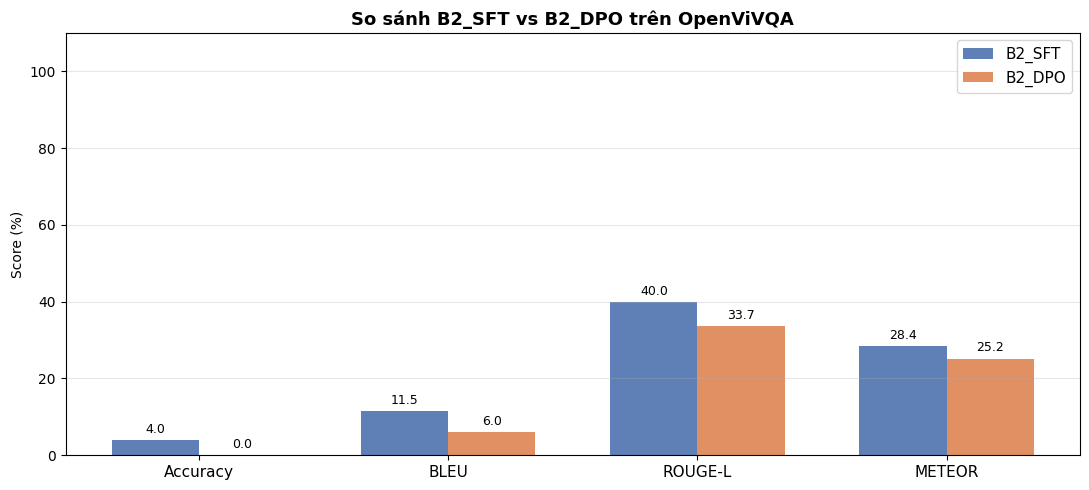

Đã lưu biểu đồ: sft_vs_dpo.png


In [12]:
import matplotlib.pyplot as plt

print("\n========== SO SÁNH CHI TIẾT 10 MẪU ĐẦU ==========")
print(f"{'Q':<45} {'GT':<25} {'SFT':<25} {'DPO':<25}")
print("-"*120)
for i in range(min(10, len(eval_set))):
    s   = eval_set[i]
    q   = s["question"][:43]
    gt  = gts_eval[i][:23]
    sft = preds_sft[i][:23]
    dpo = preds_dpo[i][:23]
    print(f"{q:<45} {gt:<25} {sft:<25} {dpo:<25}")

# Vẽ biểu đồ
metric_keys  = [k for k in metrics_sft if isinstance(metrics_sft[k], float)]
sft_vals     = [metrics_sft[k] for k in metric_keys]
dpo_vals     = [metrics_dpo[k] for k in metric_keys]
x = np.arange(len(metric_keys)); w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, sft_vals, w, label="B2_SFT", color="#4C72B0", alpha=0.9)
b2 = ax.bar(x + w/2, dpo_vals, w, label="B2_DPO", color="#DD8452", alpha=0.9)
ax.bar_label(b1, fmt="%.1f", padding=3, fontsize=9)
ax.bar_label(b2, fmt="%.1f", padding=3, fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(metric_keys, fontsize=11)
ax.set_ylabel("Score (%)"); ax.set_ylim(0, 110)
ax.set_title("So sánh B2_SFT vs B2_DPO trên OpenViVQA", fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("sft_vs_dpo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ: sft_vs_dpo.png")


In [13]:
import zipfile
import os

# Các file/folder cần đóng gói
to_zip = [
    "./qwen2vl_dpo_final",      # model DPO
    "./qwen2vl_dpo_output",     # checkpoint training
    "sft_vs_dpo.png",           # biểu đồ
    "dpo_training_log.csv",     # log training (nếu có)
]

zip_path = "/kaggle/working/result.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for path in to_zip:
        if not os.path.exists(path):
            print(f"⚠️  Bỏ qua (không tồn tại): {path}")
            continue
        if os.path.isdir(path):
            for root, dirs, files in os.walk(path):
                for file in files:
                    full_path = os.path.join(root, file)
                    arcname   = os.path.relpath(full_path, start=".")
                    zf.write(full_path, arcname)
                    print(f"  + {arcname}")
        else:
            zf.write(path, os.path.basename(path))
            print(f"  + {os.path.basename(path)}")

size_mb = os.path.getsize(zip_path) / 1024 / 1024
print(f"\nĐã tạo: {zip_path} ({size_mb:.1f} MB)")
print("Vào tab Output bên phải Kaggle để tải xuống")

  + qwen2vl_dpo_final/processor_config.json
  + qwen2vl_dpo_final/adapter_config.json
  + qwen2vl_dpo_final/README.md
  + qwen2vl_dpo_final/chat_template.jinja
  + qwen2vl_dpo_final/training_args.bin
  + qwen2vl_dpo_final/tokenizer_config.json
  + qwen2vl_dpo_final/tokenizer.json
  + qwen2vl_dpo_final/adapter_model.safetensors
  + qwen2vl_dpo_final/ref/adapter_config.json
  + qwen2vl_dpo_final/ref/adapter_model.safetensors
  + qwen2vl_dpo_output/README.md
  + qwen2vl_dpo_output/checkpoint-200/rng_state.pth
  + qwen2vl_dpo_output/checkpoint-200/adapter_config.json
  + qwen2vl_dpo_output/checkpoint-200/README.md
  + qwen2vl_dpo_output/checkpoint-200/chat_template.jinja
  + qwen2vl_dpo_output/checkpoint-200/training_args.bin
  + qwen2vl_dpo_output/checkpoint-200/scheduler.pt
  + qwen2vl_dpo_output/checkpoint-200/optimizer.pt
  + qwen2vl_dpo_output/checkpoint-200/trainer_state.json
  + qwen2vl_dpo_output/checkpoint-200/tokenizer_config.json
  + qwen2vl_dpo_output/checkpoint-200/tokenizer.j